In [49]:
import pandas as pd

In [50]:
# assign data sets as easy-to-use variables (crash_data and heat_data)
crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv')
heat_data = pd.read_csv('../data/NOW Monthly NYC Weather Data.csv')

/var/folders/vp/4774jgz130lg1phx71wsz7lh0000gn/T/ipykernel_94460/1335946872.py:2: DtypeWarning: Columns (0: BOROUGH) have mixed types. Specify dtype option on import or set low_memory=False.
  crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv')


In [51]:
crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv',
    parse_dates = ['CRASH DATE'],
    dtype = {'NUMBER OF PERSONS INJURED': 'Int64'}) # assign CRASH DATE as correct datetime format, and convert PERSONS INJURED to whole numbers

/var/folders/vp/4774jgz130lg1phx71wsz7lh0000gn/T/ipykernel_94460/627144932.py:1: DtypeWarning: Columns (0: BOROUGH) have mixed types. Specify dtype option on import or set low_memory=False.
  crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv',


In [52]:
crash_data.dtypes

CRASH DATE                       datetime64[us]
CRASH TIME                                  str
BOROUGH                                     str
ZIP CODE                                float64
LATITUDE                                float64
LONGITUDE                               float64
LOCATION                                    str
ON STREET NAME                              str
CROSS STREET NAME                           str
OFF STREET NAME                             str
NUMBER OF PERSONS INJURED                 Int64
NUMBER OF PERSONS KILLED                  int64
NUMBER OF PEDESTRIANS INJURED             int64
NUMBER OF PEDESTRIANS KILLED              int64
NUMBER OF CYCLIST INJURED                 int64
NUMBER OF CYCLIST KILLED                  int64
NUMBER OF MOTORIST INJURED                int64
NUMBER OF MOTORIST KILLED                 int64
CONTRIBUTING FACTOR VEHICLE 1               str
CONTRIBUTING FACTOR VEHICLE 2               str
CONTRIBUTING FACTOR VEHICLE 3           

In [53]:
print(crash_data['CONTRIBUTING FACTOR VEHICLE 1'].unique())

<StringArray>
[                                  'Alcohol Involvement',
                        'Driver Inattention/Distraction',
                                    'Lost Consciousness',
                                           'Unspecified',
                                    'Turning Improperly',
                         'Failure to Yield Right-of-Way',
                                   'Passing Too Closely',
                                                 'Glare',
                                      'Backing Unsafely',
                                    'Obstruction/Debris',
                                          'Unsafe Speed',
                        'Passing or Lane Usage Improper',
                           'Traffic Control Disregarded',
                        'Reaction to Uninvolved Vehicle',
                                       'Other Vehicular',
                                 'Following Too Closely',
                                     'Pavement Slippery',


In [54]:
all_values = crash_data['CONTRIBUTING FACTOR VEHICLE 1'].unique().tolist()
with open('../output/all_values.txt', 'w') as f:
    for value in all_values:
        f.write(str(value) + '\n')
    # this makes a .txt file so i can see all of them

In [55]:
# Filter to only rows with road rage
filtered = crash_data[crash_data['CONTRIBUTING FACTOR VEHICLE 1'] == 'Aggressive Driving/Road Rage']

In [56]:
filtered.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
273,2024-02-06,23:20,STATEN ISLAND,10306.0,40.568325,-74.139340,"(40.568325, -74.13934)",KENSICO STREET,WEST CEDARVIEW AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4701430,Sedan,Sedan,NaN,NaN,NaN
314,2021-08-24,15:40,STATEN ISLAND,10312.0,40.561520,-74.171860,"(40.56152, -74.17186)",ARTHUR KILL ROAD,DRUMGOOLE ROAD WEST,NaN,...,Unspecified,NaN,NaN,NaN,4450738,Sedan,Pick-up Truck,NaN,NaN,NaN
780,2025-06-21,10:00,STATEN ISLAND,10306.0,40.575480,-74.114880,"(40.57548, -74.11488)",BURBANK AVE,N RAILROAD AVE,NaN,...,Unspecified,Unspecified,Unspecified,NaN,4822749,Station Wagon/Sport Utility Vehicle,Pick-up Truck,Sedan,Sedan,NaN
816,2023-12-09,2:39,STATEN ISLAND,10312.0,40.540500,-74.177315,"(40.5405, -74.177315)",SNEDEN AVENUE,ANNADALE ROAD,NaN,...,NaN,NaN,NaN,NaN,4685949,NaN,NaN,NaN,NaN,NaN
1071,2023-12-30,20:40,STATEN ISLAND,10304.0,40.598503,-74.091934,"(40.598503, -74.091934)",RICHMOND ROAD,HUNTON STREET,NaN,...,Unspecified,Unspecified,Unspecified,Unspecified,4691570,Station Wagon/Sport Utility Vehicle,Sedan,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle


In [57]:
filtered = filtered[['CRASH DATE', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'COLLISION_ID']]

In [58]:
filtered.head()

,CRASH DATE,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID
273,2024-02-06,0,0,Aggressive Driving/Road Rage,4701430
314,2021-08-24,0,0,Aggressive Driving/Road Rage,4450738
780,2025-06-21,0,0,Aggressive Driving/Road Rage,4822749
816,2023-12-09,1,0,Aggressive Driving/Road Rage,4685949
1071,2023-12-30,1,0,Aggressive Driving/Road Rage,4691570


In [59]:
len(filtered)

4089

In [60]:
filtered_with_injuries = filtered[(filtered['NUMBER OF PEDESTRIANS INJURED'] > 0) | (filtered['NUMBER OF PEDESTRIANS KILLED'] > 0)]

In [61]:
filtered_with_injuries.head()

,CRASH DATE,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID
816,2023-12-09,1,0,Aggressive Driving/Road Rage,4685949
1071,2023-12-30,1,0,Aggressive Driving/Road Rage,4691570
1111,2025-10-14,1,0,Aggressive Driving/Road Rage,4849723
2998,2022-05-13,2,0,Aggressive Driving/Road Rage,4528684
3131,2021-06-27,1,0,Aggressive Driving/Road Rage,4436208


In [62]:
len(filtered_with_injuries)

496

In [63]:
filtered_with_injuries['YR-M'] = filtered_with_injuries['CRASH DATE'].dt.to_period('M') # turns days into YEAR-MONTH format


In [64]:
filtered_with_injuries.head()

,CRASH DATE,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,YR-M
816,2023-12-09,1,0,Aggressive Driving/Road Rage,4685949,2023-12
1071,2023-12-30,1,0,Aggressive Driving/Road Rage,4691570,2023-12
1111,2025-10-14,1,0,Aggressive Driving/Road Rage,4849723,2025-10
2998,2022-05-13,2,0,Aggressive Driving/Road Rage,4528684,2022-05
3131,2021-06-27,1,0,Aggressive Driving/Road Rage,4436208,2021-06


In [65]:
# Group by month and aggregate injury counts
monthly_roadrage_data = filtered_with_injuries.groupby('YR-M').agg({
    'NUMBER OF PEDESTRIANS INJURED': ['sum'],
    'NUMBER OF PEDESTRIANS KILLED': ['sum'],
}).reset_index()

# Flatten column names
monthly_roadrage_data.columns = ['YR-M', 'Ped_Injuries_Sum', 'Ped_Deaths_Sum']

In [66]:
monthly_roadrage_data.head()

,YR-M,Ped_Injuries_Sum,Ped_Deaths_Sum
0,2021-01,4,0
1,2021-03,4,0
2,2021-04,5,0
3,2021-05,8,0
4,2021-06,12,0


In [67]:
monthly_roadrage_data.dtypes

YR-M                period[M]
Ped_Injuries_Sum        int64
Ped_Deaths_Sum          int64
dtype: object

In [68]:
monthly_roadrage_data = monthly_roadrage_data.astype({'YR-M': 'str'}) # change the YR-M column into a str to match the heat_data_fixed YRM column

In [69]:
monthly_roadrage_data.dtypes

YR-M                  str
Ped_Injuries_Sum    int64
Ped_Deaths_Sum      int64
dtype: object

In [70]:
monthly_roadrage_data.head()

,YR-M,Ped_Injuries_Sum,Ped_Deaths_Sum
0,2021-01,4,0
1,2021-03,4,0
2,2021-04,5,0
3,2021-05,8,0
4,2021-06,12,0


In [71]:
heat_data.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual_Avg
0,2021,44.0,46.5,67,68.5,78.0,86.5,85.0,86.0,78.0,71.0,59.0,58.0,86.5
1,2022,53.0,58.5,62,68.0,80.5,81.5,87.0,87.5,80.5,67.0,70.5,56.5,87.5
2,2023,57.5,63.0,55,80.5,76.0,78.5,83.5,80.5,85.0,74.5,59.5,55.5,85.0
3,2024,52.5,53.5,62,75.0,76.0,85.0,86.0,85.5,77.0,71.5,72.0,55.0,86.0
4,2025,45.0,50.0,62,69.5,74.0,90.0,87.5,82.0,76.0,74.0,59.5,45.0,90.0


In [72]:
heat_data_fixed = heat_data.melt(id_vars=['Year'],
    value_vars=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    var_name='Month',
    value_name='Temperature')
# this turns heat_data, which is a table, into the long format we need it to be so we can compare

In [73]:
# Map month names to numbers
month_numbers = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
             'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
heat_data_fixed['Month_Num'] = heat_data_fixed['Month'].map(month_numbers)
# this basically turns Month Names in month numbers

# Create Year-Month in format to match monthly_crash_data
heat_data_fixed['YearMonth'] = heat_data_fixed['Year'].astype(str) + '-' + heat_data_fixed['Month_Num']
# this combines the month numbers and year values into the YR-M format we are using on the pedestrian injury data

In [74]:
heat_data_fixed.head()

,Year,Month,Temperature,Month_Num,YearMonth
0,2021,Jan,44.0,01,2021-01
1,2022,Jan,53.0,01,2022-01
2,2023,Jan,57.5,01,2023-01
3,2024,Jan,52.5,01,2024-01
4,2025,Jan,45.0,01,2025-01


In [75]:
heat_data_fixed = heat_data_fixed[['Temperature', 'YearMonth']] # we don't need the extra columns, just the YR-M and the avg temperature

In [76]:
heat_data_fixed.dtypes

Temperature    float64
YearMonth          str
dtype: object

In [77]:
heat_data_fixed = heat_data_fixed.rename(columns={'YearMonth': 'YR-M'}) # rename the YearMonth column to YR-M so we can merge it better

In [78]:
heat_data_fixed.head()

,Temperature,YR-M
0,44.0,2021-01
1,53.0,2022-01
2,57.5,2023-01
3,52.5,2024-01
4,45.0,2025-01


In [79]:
combined_data = monthly_roadrage_data.merge(heat_data_fixed, left_on='YR-M', right_on='YR-M', how='left')

In [80]:
combined_data.head()

,YR-M,Ped_Injuries_Sum,Ped_Deaths_Sum,Temperature
0,2021-01,4,0,44.0
1,2021-03,4,0,67.0
2,2021-04,5,0,68.5
3,2021-05,8,0,78.0
4,2021-06,12,0,86.5


In [81]:
len(combined_data)

59

In [82]:
combined_data.tail()

,YR-M,Ped_Injuries_Sum,Ped_Deaths_Sum,Temperature
54,2025-08,6,0,82.0
55,2025-09,22,1,76.0
56,2025-10,10,0,74.0
57,2025-11,10,0,59.5
58,2025-12,13,0,45.0


In [83]:
len(heat_data_fixed)

60

In [84]:
len(monthly_roadrage_data)

59

In [85]:
all_months = pd.date_range('2021-01', '2025-12', freq='ME').strftime('%Y-%m')
missing_months = [m for m in all_months if m not in combined_data['YR-M'].values]
print(f"Missing months: {missing_months}")

# find the missing month

Missing months: ['2021-02']


In [86]:
# Create a new row for the missing month
missing_row = pd.DataFrame({
    'YR-M': ['2021-02'],
    'Ped_Injuries_Sum': [0],
    'Ped_Deaths_Sum': [0],
    'Temperature': [heat_data_fixed[heat_data_fixed['YR-M'] == '2021-02']['Temperature'].values[0]]
})

# Append it to combined_data
combined_data = pd.concat([combined_data, missing_row], ignore_index=True)

# Sort by YR-M to keep it in order
combined_data = combined_data.sort_values('YR-M').reset_index(drop=True)

In [87]:
len(combined_data)

60

In [88]:
correlation = combined_data['Temperature'].corr(combined_data['Ped_Injuries_Sum'])
print(correlation)

0.23635286269809774


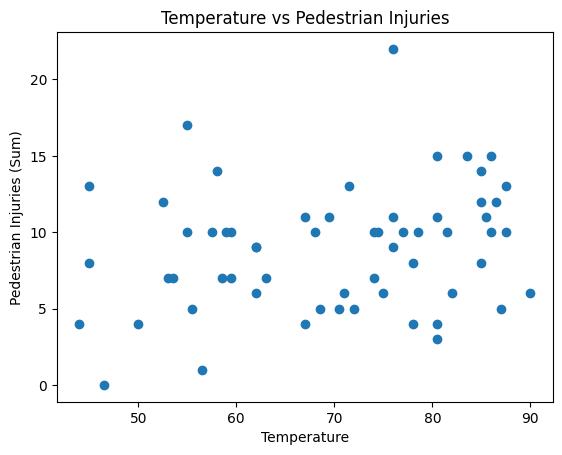

In [89]:
import matplotlib.pyplot as plt

plt.scatter(combined_data['Temperature'], combined_data['Ped_Injuries_Sum'])
plt.xlabel('Temperature')
plt.ylabel('Pedestrian Injuries (Sum)')
plt.title('Temperature vs Pedestrian Injuries')
plt.show()

# using the matplotlib to create a scatter plot so I can visualize, because the correlation number was not expected 